# Barcelona Noise Prediction: Building Use Feature Engineering

This notebook evaluates the `currentUse` attribute of Cadastral buildings to derive usage percentages around our street network.
We load the `bcn_catastral_building.gpkg` layer and calculate the proportion of each building use (e.g., residential, retail, industrial) within 50m and 100m street buffers.

Hell yes! Finding that column is a massive win for 3D modeling.

To answer your question for your research: According to the Spanish Cadastre's application of the INSPIRE data model, the `currentUse` attribute is evaluated based on the **predominant use** of the building. It does **not** look at just the ground floor, nor does it arbitrarily pick a single unit.

The Spanish Cadastre calculates and assigns the INSPIRE data as follows:
* **The Predominant Surface Area Rule:** The value for `currentUse` is obtained by calculating the use that covers the most surface area where the building is located.
* **Standardized Values:** The Cadastre translates these majority uses into specific INSPIRE categories, such as `1_residential`, `2_agriculture`, `3_industrial`, `4_1_office`, `4_2_retail`, and `4_3_publicServices`.
* **The Internal vs. Export Reality:** In Spain's internal database, the Cadastre registers the use of different elements separately, meaning it records the specific use of a home alongside its garage and storage room, or the different basements and heights of a property. However, because the INSPIRE 3D model requires a single use per polygon, the system aggregates the square meters of all those internal units and assigns the "winning" category to the `currentUse` field.

In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Loading spatial data...")
# Load streets
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index

# Load cadastral buildings
buildings = gpd.read_file("../../layers/bcn_catastral_building.gpkg")

# Ensure CRS alignment
buildings = buildings.to_crs(noise_streets.crs)

print(f"Loaded {len(noise_streets)} streets and {len(buildings)} buildings.")
display(buildings[['gml_id', 'currentUse', 'geometry']].head())

Loading spatial data...
Loaded 15115 streets and 69893 buildings.


,gml_id,currentUse,geometry
0,ES.SDGC.BU.0004701DF3800C,1_residential,"MULTIPOLYGON (((429972.94 4580072.933, 429946...."
1,ES.SDGC.BU.0004702DF3800C,4_3_publicServices,"MULTIPOLYGON (((429891.252 4580183.734, 429903..."
2,ES.SDGC.BU.0005401DF3800E,1_residential,"MULTIPOLYGON (((429957.363 4580401.054, 429956..."
3,ES.SDGC.BU.0005403DF3800E,1_residential,"MULTIPOLYGON (((429981.014 4580406.584, 429982..."
4,ES.SDGC.BU.0005404DF3800E,1_residential,"MULTIPOLYGON (((429987.824 4580410.624, 429987..."


## Clean and Map Building Uses

The Cadastral `currentUse` has predefined codes like `1_residential` and `4_2_retail`. We can simplify these into machine-learning friendly categories.

currentUse
1_residential         61874
4_2_retail             2421
4_3_publicServices     1985
3_industrial           1748
4_1_office             1253
NaN                     417
2_agriculture           195
Name: count, dtype: int64


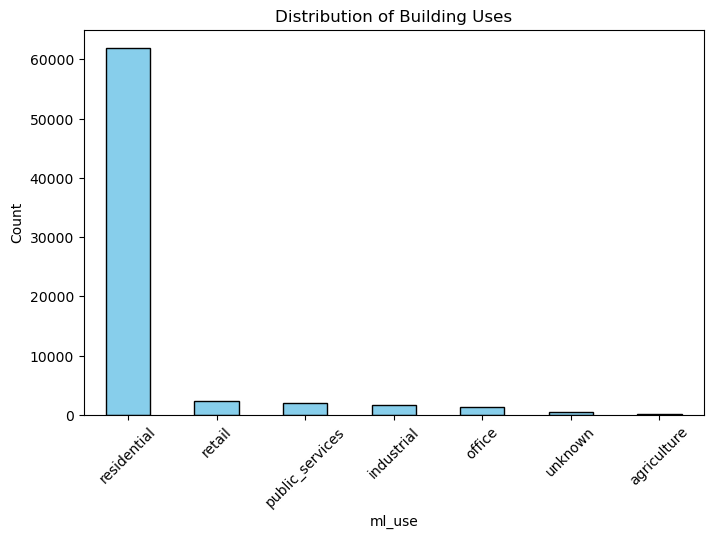

In [7]:
print(buildings['currentUse'].value_counts(dropna=False))

# Mapping dictionary for cleaner feature names
use_mapping = {
    '1_residential': 'residential',
    '4_2_retail': 'retail',
    '4_3_publicServices': 'public_services',
    '3_industrial': 'industrial',
    '4_1_office': 'office',
    '2_agriculture': 'agriculture'
}

# Apply mapping, filling NaNs or unmapped with 'unknown'
buildings['ml_use'] = buildings['currentUse'].map(use_mapping).fillna('unknown')

fig, ax = plt.subplots(figsize=(8, 5))
buildings['ml_use'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', ax=ax)
ax.set_title("Distribution of Building Uses")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Calculate Buffer Area Percentages

We use spatial overlays to calculate what percentage of the buffer zone is occupied by each building use type.

In [8]:
def calculate_building_use_pct(streets_gdf, bldgs_gdf, buffer_size):
    print(f"Processing {buffer_size}m buffers...")
    
    # Create buffers and compute their total area
    buffered = streets_gdf[['fid', 'TRAM', 'geometry']].copy()
    buffered['geometry'] = buffered.geometry.buffer(buffer_size)
    buffered['buffer_area'] = buffered.geometry.area
    
    # Optional performance optimization: keep only needed columns in buildings
    b_reduced = bldgs_gdf[['ml_use', 'geometry']].copy()
    
    # Intersect buffers with building footprints to find exact overlapping areas
    intersection = gpd.overlay(buffered, b_reduced, how='intersection')
    intersection['intersected_area'] = intersection.geometry.area
    
    # Group by street identifier and building use, then sum up intersected area
    grouped = intersection.groupby(['fid', 'TRAM', 'ml_use'])['intersected_area'].sum().reset_index()
    
    # Merge buffer total area back in to divide and derive percentages
    grouped = grouped.merge(buffered[['fid', 'TRAM', 'buffer_area']], on=['fid', 'TRAM'])
    grouped['pct'] = (grouped['intersected_area'] / grouped['buffer_area']) * 100
    
    # Pivot into wide format for machine learning integration
    features = grouped.pivot(index=['fid', 'TRAM'], columns='ml_use', values='pct').fillna(0)
    
    # Tag column names with the buffer size designation
    features.columns = [f"bldg_{col}_pct_{buffer_size}m" for col in features.columns]
    
    return features.reset_index()

features_50m = calculate_building_use_pct(noise_streets, buildings, 50)
features_100m = calculate_building_use_pct(noise_streets, buildings, 100)

display(features_50m.head())

Processing 50m buffers...
Processing 100m buffers...


,fid,TRAM,bldg_agriculture_pct_50m,bldg_industrial_pct_50m,bldg_office_pct_50m,bldg_public_services_pct_50m,bldg_residential_pct_50m,bldg_retail_pct_50m,bldg_unknown_pct_50m
0,0,T04719W,0.0,0.000000,0.000000,1.866269,27.543661,5.552877,0.000000
1,1,T19941Z,0.0,3.870967,0.000000,0.000000,44.692916,0.000000,0.573464
2,2,T18111R,0.0,0.000000,2.792330,0.000000,8.694119,0.000000,8.888457
3,3,T03222Y,0.0,0.000000,0.705974,0.000000,37.877471,6.344014,0.000000
4,4,T17625I,0.0,0.000000,0.000000,0.000000,8.154331,0.000000,0.000000


## Compile Final Dataset and Export

Merge the percentages generated back onto our core layout indexed by `fid` and `TRAM`, and export the DataFrame.

In [9]:
# Baseline dataset structure
dataset = pd.DataFrame({
    'fid': noise_streets['fid'],
    'street_id': noise_streets['TRAM']
})

# Attach all features
dataset = dataset.merge(features_50m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')
dataset = dataset.merge(features_100m, left_on=['fid', 'street_id'], right_on=['fid', 'TRAM'], how='left').drop(columns=['TRAM'], errors='ignore')

dataset = dataset.fillna(0)
display(dataset.head())

# Export the engineered feature CSV
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "building_use_features.csv"), index=False)
print("Successfully generated and exported: building_use_features.csv")

,fid,street_id,bldg_agriculture_pct_50m,bldg_industrial_pct_50m,bldg_office_pct_50m,bldg_public_services_pct_50m,bldg_residential_pct_50m,bldg_retail_pct_50m,bldg_unknown_pct_50m,bldg_agriculture_pct_100m,bldg_industrial_pct_100m,bldg_office_pct_100m,bldg_public_services_pct_100m,bldg_residential_pct_100m,bldg_retail_pct_100m,bldg_unknown_pct_100m
0,0,T04719W,0.0,0.000000,0.000000,1.866269,27.543661,5.552877,0.000000,0.0,2.270644,0.000000,6.241136,26.091768,3.050601,0.000000
1,1,T19941Z,0.0,3.870967,0.000000,0.000000,44.692916,0.000000,0.573464,0.0,2.074382,0.000000,0.000000,38.380829,0.012142,0.194597
2,2,T18111R,0.0,0.000000,2.792330,0.000000,8.694119,0.000000,8.888457,0.0,0.000000,0.933766,2.567258,8.928993,0.000000,2.986843
3,3,T03222Y,0.0,0.000000,0.705974,0.000000,37.877471,6.344014,0.000000,0.0,0.000000,0.898726,0.861456,32.738005,2.341251,0.000000
4,4,T17625I,0.0,0.000000,0.000000,0.000000,8.154331,0.000000,0.000000,0.0,0.000000,0.315134,0.000000,16.135113,0.000000,0.000000


Successfully generated and exported: building_use_features.csv


## Mapping Output Results

Let's visualize the resulting physical footprint to verify our generated residential concentrations along the streets.

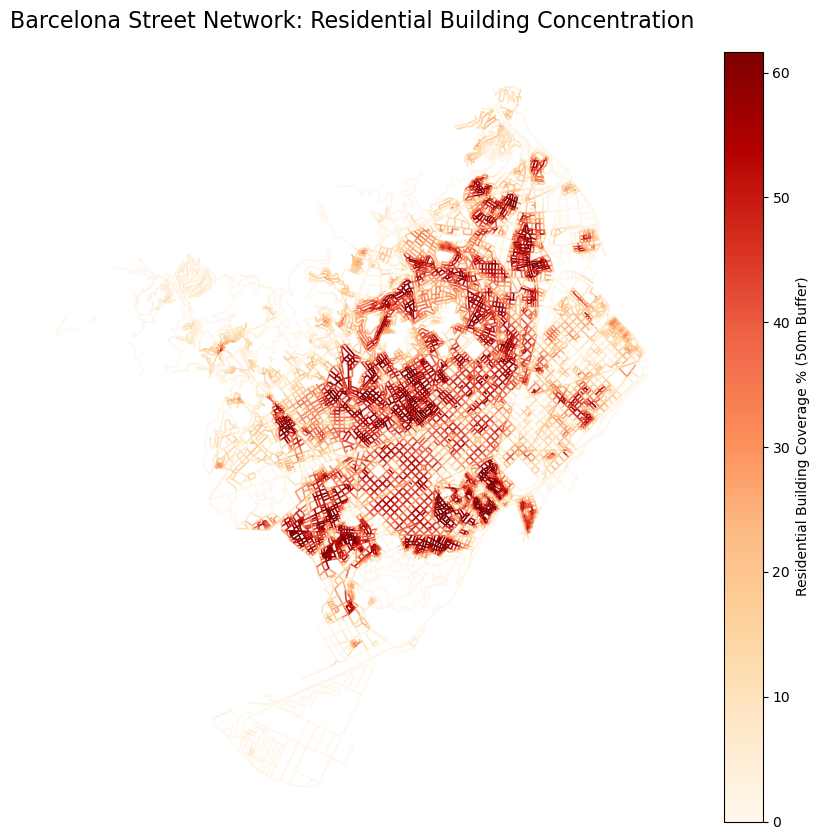

In [10]:
viz_gdf = noise_streets.merge(dataset[['fid', 'bldg_residential_pct_50m']], on='fid')

fig, ax = plt.subplots(figsize=(12, 10))

# Cap at the 95th percentile so localized huge residential blocks don't fade out smaller blocks visually
vmax_val = viz_gdf['bldg_residential_pct_50m'].quantile(0.95)

viz_gdf.plot(
    column='bldg_residential_pct_50m',
    ax=ax,
    cmap='OrRd',
    linewidth=1.2,
    legend=True,
    legend_kwds={'label': "Residential Building Coverage % (50m Buffer)"},
    vmax=vmax_val
)

ax.set_title("Barcelona Street Network: Residential Building Concentration", fontsize=16)
ax.set_axis_off()
plt.show()